<a href="https://colab.research.google.com/github/fviniciussilva/ape/blob/main/Experimento_de_Inser%C3%A7%C3%A3o_em_Estruturas_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando bateria de testes. Isso pode levar alguns segundos...

Carga: 20000 concluída.
Carga: 40000 concluída.
Carga: 60000 concluída.
Carga: 80000 concluída.
Carga: 100000 concluída.

TABELA FINAL DE MÉTRICAS DO EXPERIMENTO
 Tamanho do Dataset (N)  Tempo Arranjo (segundos)  Tempo Lista Encadeada (segundos)
                  20000                  0.188336                          0.123754
                  40000                  0.908158                          0.060060
                  60000                  2.348983                          0.139874
                  80000                  3.658684                          0.125426
                 100000                  1.805054                          0.162504

Gráfico renderizado e salvo como 'grafico.png'. Pronto para o Overleaf e Zenodo!


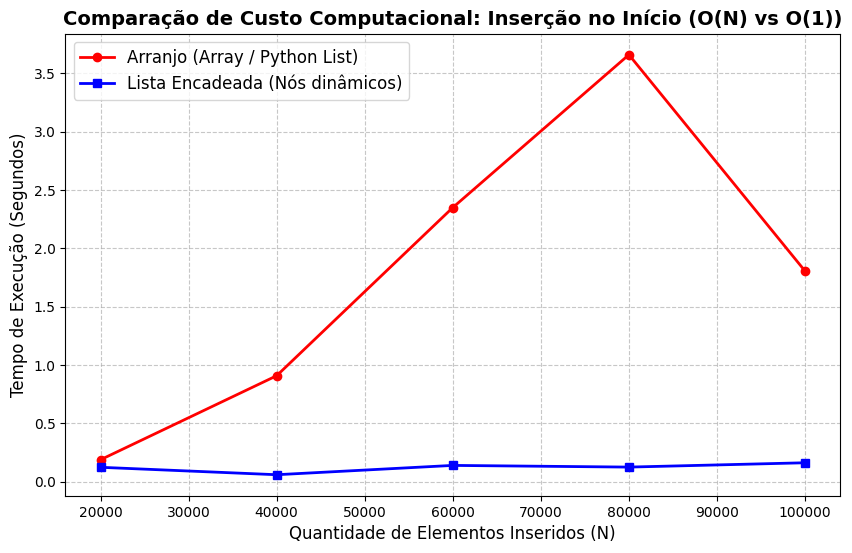

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. IMPLEMENTAÇÃO DAS ESTRUTURAS DE DADOS
# ==========================================

class Node:
    """Nó fundamental da Lista Encadeada contendo o dado e o ponteiro lógico."""
    def __init__(self, data):
        self.data = data
        self.next = None

class LinkedList:
    """Implementação limpa de uma Lista Encadeada para o experimento."""
    def __init__(self):
        self.head = None

    def prepend(self, data):
        """Inserção no início: Complexidade O(1)"""
        new_node = Node(data)
        new_node.next = self.head
        self.head = new_node

# ==========================================
# 2. LÓGICA DE BENCHMARKING
# ==========================================

def medir_tempo_insercao_arranjo(n_elementos):
    """Mede o tempo para inserir N elementos no início de um Array (Lista nativa)."""
    arranjo = []
    inicio = time.time()
    for i in range(n_elementos):
        arranjo.insert(0, i) # Força o deslocamento O(N) na memória
    fim = time.time()
    return fim - inicio

def medir_tempo_insercao_encadeada(n_elementos):
    """Mede o tempo para inserir N elementos no início de uma Lista Encadeada."""
    lista_enc = LinkedList()
    inicio = time.time()
    for i in range(n_elementos):
        lista_enc.prepend(i) # Manipulação de ponteiro O(1)
    fim = time.time()
    return fim - inicio

def executar_experimento(cargas_trabalho):
    """Orquestra o experimento e coleta as métricas."""
    resultados = []

    print("Iniciando bateria de testes. Isso pode levar alguns segundos...\n")

    for n in cargas_trabalho:
        tempo_arr = medir_tempo_insercao_arranjo(n)
        tempo_enc = medir_tempo_insercao_encadeada(n)

        resultados.append({
            "Tamanho do Dataset (N)": n,
            "Tempo Arranjo (segundos)": tempo_arr,
            "Tempo Lista Encadeada (segundos)": tempo_enc
        })

        print(f"Carga: {n} concluída.")

    return pd.DataFrame(resultados)

# ==========================================
# 3. EXECUÇÃO E GERAÇÃO DE ARTEFATOS
# ==========================================

if __name__ == "__main__":
    # Define os degraus de dados para o teste (Cenário prático e robusto)
    cargas = [20000, 40000, 60000, 80000, 100000]

    # Roda o experimento
    df_resultados = executar_experimento(cargas)

    # Exibe a tabela de dados finais no terminal (Formato para artigo)
    print("\n" + "="*60)
    print("TABELA FINAL DE MÉTRICAS DO EXPERIMENTO")
    print("="*60)
    print(df_resultados.to_string(index=False))
    print("="*60 + "\n")

    # Plotagem do Gráfico Comparativo
    plt.figure(figsize=(10, 6))
    plt.plot(df_resultados['Tamanho do Dataset (N)'], df_resultados['Tempo Arranjo (segundos)'],
             marker='o', linestyle='-', color='red', linewidth=2, label='Arranjo (Array / Python List)')

    plt.plot(df_resultados['Tamanho do Dataset (N)'], df_resultados['Tempo Lista Encadeada (segundos)'],
             marker='s', linestyle='-', color='blue', linewidth=2, label='Lista Encadeada (Nós dinâmicos)')

    # Estilização do Gráfico
    plt.title('Comparação de Custo Computacional: Inserção no Início (O(N) vs O(1))', fontsize=14, fontweight='bold')
    plt.xlabel('Quantidade de Elementos Inseridos (N)', fontsize=12)
    plt.ylabel('Tempo de Execução (Segundos)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Salva o gráfico conforme a requisição metodológica
    plt.savefig('grafico.png', dpi=300, bbox_inches='tight')
    print("Gráfico renderizado e salvo como 'grafico.png'. Pronto para o Overleaf e Zenodo!")

    # Exibe o gráfico no output do Colab
    plt.show()